In [4]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import bptf
from bptf import BPTF
import numpy as np
import pandas as pd
import sparse
import os
import shutil
from tqdm import tqdm
import pickle
import scipy.stats as st
import matplotlib.pyplot as plt
import torch
import tensorly
import cupy

import multiprocessing
from joblib import Parallel, delayed
from tqdm.contrib.concurrent import process_map

print(os.getcwd())

import gc
gc.collect()

<IPython.core.display.Javascript object>

Kernel is restarting...
c:\Users\luiyu\Documents\aaron_schein\bptf_new


3956

In [ ]:
parallel = False

folder = "/icews_gdelt_terrier/"
data_filepath = os.getcwd() + folder
files = os.listdir(data_filepath)
if parallel:
    files = Parallel(n_jobs=multiprocessing.cpu_count())(
        delayed(pd.read_csv)(data_filepath + filepath)
        for filepath in tqdm(files, desc = 'Reading data')
    )
    data = pd.concat(files)
    data = data.sort_values(by='Num_Events', ascending=False)
else:
    data = [pd.read_csv(data_filepath + filepath) for filepath in tqdm(files, desc = 'Reading data')]
    data = pd.concat(data)
    data = data.sort_values(by='Num_Events', ascending=False)

# get GDELT data from GDELT database to replace gdelt in original data
gdelt_filepaths = [os.path.join('GDELT', f) for f in os.listdir('GDELT')]
# gdelt = [pd.read_csv(gdelt_filepath, dtype={'EventBaseCode': str}) for gdelt_filepath in gdelt_filepaths]

def read_gdelt(filepath):
    gdelt = pd.read_csv(filepath, dtype={'EventBaseCode': str})
    colnames = data.columns
    gdelt = gdelt.rename(columns={'Actor1CountryCode' : colnames[0],
                                'Actor2CountryCode' : colnames[1],
                                'EventBaseCode' : colnames[2],
                                'SQLDATE' : colnames[3],
                                'NumMentions' : colnames[4]})
    gdelt = gdelt[gdelt['CAMEO_Code'].str.isnumeric()]
    gdelt['CAMEO_Code'] = gdelt['CAMEO_Code'].astype(int)
    gdelt['formatteddate'] = gdelt['formatteddate'].astype(str)
    gdelt['formatteddate'] = pd.to_datetime(gdelt['formatteddate'], format='%Y%m%d')
    # gdelt['formatteddate'] = gdelt['formatteddate'].dt.strftime('%Y-%m-%d')
    return gdelt

if parallel:
    if __name__ == '__main__':
        gdelt = Parallel(n_jobs = multiprocessing.cpu_count())(
            delayed(read_gdelt)(gdelt_filepath)
            for gdelt_filepath in tqdm(gdelt_filepaths, desc='Reading GDELT data')
            )
else:
    gdelt = [read_gdelt(gdelt_filepath) for gdelt_filepath in tqdm(gdelt_filepaths, desc='Reading GDELT data')]

gdelt = pd.concat(gdelt)

# combine the data
# we stack the data since the downloaded GDELT data is from before 2015 and the bigquery one is post-2015
# data = data[data['Database'] != 'GDELT']
gdelt['Database'] = 'GDELT'

Reading GDELT data: 100%|██████████| 21/21 [00:16<00:00,  1.31it/s]


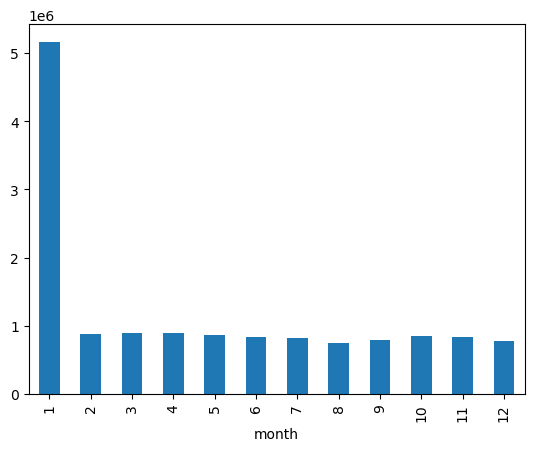

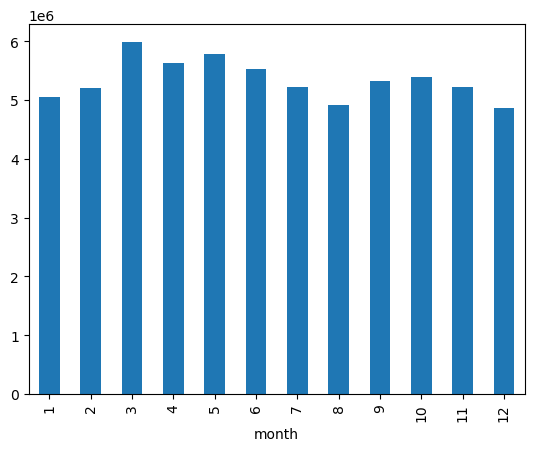

In [ ]:
# gdelt['formatteddate'] = pd.to_datetime(gdelt['formatteddate'])
gdelt['month'] = gdelt['formatteddate'].dt.month

month_counts = gdelt['month'].value_counts().sort_index()

month_counts.plot(kind='bar')
plt.show()

data['formatteddate'] = pd.to_datetime(data['formatteddate'])
data['month'] = data['formatteddate'].dt.month

month_counts = data['month'].value_counts().sort_index()

month_counts.plot(kind='bar')
plt.show()
